Using Qwen-utils module for object recognition. Our image contains fruits and vegetables in a supermarket store/market.

In [1]:
pip install qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 33.8 MB/s eta 0:00:00


Import all libraries.

In [2]:
import os          # File‑system helpers (paths, env vars, etc.)
import random      # Lightweight randomness (e.g. sample prompts)
import textwrap    # Nicely format long strings for display
import io          # In‑memory byte streams (e.g. image buffers)
import requests    # Simple HTTP requests for downloading assets
import re          # Regular expression operations
import json        # Functions for working with JSON data (parse, serialize)
import pprint      # Pretty print JSON

import numpy as np  # Core array maths (fast, vectorised operations)

import numpy as np  # Core array maths (fast, vectorised operations)

import torch  # Tensor library + GPU acceleration
from transformers import (
    Qwen2_5_VLForConditionalGeneration,  # Multimodal LLM (image+text)
    AutoProcessor,                       # Paired tokenizer/feature‑extractor
)

from PIL import (
    Image,        # Core class for opening, manipulating, and saving images
    ImageDraw,    # Module for drawing on images (shapes, text, etc.)
    ImageFont,    # Module for working with different fonts when drawing text
    ImageColor    # Utility for converting color names/formats to Pillow color values
)
import matplotlib.pyplot as plt          # Quick plots in notebooks
import matplotlib.patches as patches     # Bounding‑box overlays, etc.

from qwen_vl_utils import process_vision_info  # Post‑process Qwen outputs
import IPython.display as ipd             # Inline display (images, audio, HTML)
from IPython.display import display


Load image from Wikipedia.

In [3]:
import re
from urllib.parse import urlparse, unquote

wiki_page_url = 'https://en.wikipedia.org/wiki/Vegetable#/media/File:Veggies.jpg'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

try:
    # Step 1: Parse the Wikipedia URL to get the media file name
    parsed_url = urlparse(wiki_page_url)
    fragment = parsed_url.fragment # e.g., 'media/File:Marketvegetables.jpg'

    # Extract the 'File:...' part
    match_filename = re.search(r'(File:[^/]+)$', fragment)
    if not match_filename:
        print("Could not extract filename from the Wikipedia URL fragment.")
        raise ValueError("Filename not found in URL fragment.")

    filename_encoded = match_filename.group(0) # e.g., 'File:Marketvegetables.jpg'
    filename = unquote(filename_encoded) # Decode any URL-encoded characters

    # Step 2: Construct the Wikimedia Commons page URL for the image
    # Example: https://commons.wikimedia.org/wiki/File:Marketvegetables.jpg
    wikimedia_commons_url = f"https://commons.wikimedia.org/wiki/{filename}"
    print(f"Constructed Wikimedia Commons URL: {wikimedia_commons_url}")

    # Step 3: Get the HTML content of the Wikimedia Commons page
    response_commons_page = requests.get(wikimedia_commons_url, headers=headers)
    response_commons_page.raise_for_status()
    commons_html_content = response_commons_page.text

    # Step 4: Extract the actual image URL from the Commons HTML
    # This regex looks for an <a> tag with an href to upload.wikimedia.org/wikipedia/commons/
    # and has 'Original file' as its text content.
    image_url_match = re.search(r'<a href="(https://upload\.wikimedia\.org/wikipedia/commons/[^\"]+\.(?:jpg|jpeg|png|gif|svg|webp))"[^>]*>Original file</a>', commons_html_content, re.IGNORECASE)

    if image_url_match:
        image_url = image_url_match.group(1) # Group 1 captures the full image URL
        print(f"Found image URL: {image_url}")

        # Step 5: Download the actual image
        response_image = requests.get(image_url, headers=headers, stream=True)
        response_image.raise_for_status()

        # Debugging information for image download
        print(f"Image Download HTTP Status Code: {response_image.status_code}")
        print(f"Image Content-Type: {response_image.headers.get('Content-Type')}")

        # Save the image content to a file
        with open('Marketvegetables.jpg', 'wb') as f:
            for chunk in response_image.iter_content(chunk_size=8192):
                f.write(chunk)
        im = Image.open('Marketvegetables.jpg')
        display(im)
    else:
        print("Could not find a direct image URL on the Wikimedia Commons page using the defined pattern.")

except requests.exceptions.RequestException as e:
    print(f"Error during request: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Output hidden; open in https://colab.research.google.com to view.

In [4]:
def _repair_newlines_inside_strings(txt: str) -> str:
    """
    Replace raw newlines that occur *inside* JSON string literals with a space.
    Very lightweight: it simply looks for a quote, then any run of characters
    that is NOT a quote or backslash, then a newline, then continues…
    """
    pattern = re.compile(r'("([^"\\]|\\.)*)\n([^"]*")')
    while pattern.search(txt):
        txt = pattern.sub(lambda m: m.group(1) + r'\n' + m.group(3), txt)
    return txt

def extract_json(code_block: str, parse: bool = True):
    """
    Remove Markdown code-block markers (``` or ```json) and return:
      • the raw JSON string   (parse=False, default)
      • the parsed Python obj (parse=True)
    """
    # Look for triple-backtick blocks, optionally tagged with a language (e.g. ```json)
    block_re = re.compile(r"```(?:\w+)?\s*(.*?)\s*```", re.DOTALL)
    m = block_re.search(code_block)
    payload = (m.group(1) if m else code_block).strip()
    if parse:
        try:
            return json.loads(payload)
        except json.JSONDecodeError as e:
            # attempt a mild repair and retry once
            payload_fixed = _repair_newlines_inside_strings(payload)
            return json.loads(payload_fixed)
    else:
        return payload

In [5]:
def display_image(im, title="Image"):
  # Display the image
  plt.figure(figsize=(8, 8))
  plt.imshow(im)
  plt.axis("off")
  plt.title(title)
  plt.show()

Define boxes and text properties.

In [6]:
def _text_wh(draw, text, font):
    """
    Return (width, height) of *text* under the given *font*, coping with
    Pillow ≥10.0 (textbbox) and older versions (textsize).
    """
    # Check if the draw object has the 'textbbox' method (Pillow >= 8.0)
    if hasattr(draw, "textbbox"): # Pillow ≥8.0, preferred
        # Get the bounding box of the text
        left, top, right, bottom = draw.textbbox((0, 0), text, font=font)
        # Calculate and return the width and height
        return right - left, bottom - top
    # Check if the draw object has the 'textsize' method (Pillow < 10.0)
    elif hasattr(draw, "textsize"): # Pillow <10.0
        # Get the size of the text
        return draw.textsize(text, font=font)
    # Fallback for other or older versions of Pillow
    else: # Fallback
        # Get the bounding box from the font itself
        left, top, right, bottom = font.getbbox(text)
        # Calculate and return the width and height
        return right - left, bottom - top


def draw_bboxes(
    im,
    detections,
    box_color="red",
    box_width=3,
    font_size=32,
    text_color="white",
    text_bg="red",
):
    # Create a drawing object for the image
    draw = ImageDraw.Draw(im)
    try:
        # Try to load a TrueType font
        font = ImageFont.truetype("DejaVuSans.ttf", font_size)
    except OSError:
        # If TrueType font is not found, load the default font
        font = ImageFont.load_default(font_size)

    # Iterate through each detected object
    for det in detections:
        # Extract bounding box coordinates
        x1, y1, x2, y2 = det["bbox_2d"]
        # Get the label of the detected object, default to empty string if not present
        label = str(det.get("label", ""))

        # Draw the rectangle (bounding box) on the image
        draw.rectangle([x1, y1, x2, y2], outline=box_color, width=box_width)

        # If a label exists, draw the label text
        if label:
            # Get the width and height of the text label
            tw, th = _text_wh(draw, label, font)
            # Set padding around the text
            pad = 2
            # Calculate the top-left x-coordinate for the text background
            tx1 = x1
            # Calculate the top-left y-coordinate for the text background, ensuring it stays within the top edge of the image
            ty1 = max(0, y1 - th - 2 * pad) # keep inside top edge
            # Calculate the bottom-right x-coordinate for the text background
            tx2 = x1 + tw + 2 * pad
            # Calculate the bottom-right y-coordinate for the text background
            ty2 = ty1 + th + 2 * pad

            # If a text background color is specified, draw the background rectangle
            if text_bg:
                draw.rectangle([tx1, ty1, tx2, ty2],
                               fill=text_bg, outline=box_color)
            # Draw the text label on the image
            draw.text((tx1 + pad, ty1 + pad), label,
                      fill=text_color, font=font)

    # Return the modified image with bounding boxes and labels
    return im

In [7]:
# Check if a CUDA-enabled GPU is available and set the device accordingly.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Define the identifier for the specific pre-trained Qwen 2.5-VL model to be loaded.
model_id = "Qwen/Qwen2.5-VL-7B-Instruct"

# Load the pre-trained multimodal model from the specified identifier.
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    # Automatically select the appropriate data type (FP16 on GPU, FP32 on CPU) for efficiency.
    torch_dtype="auto",
    # Automatically distribute the model's layers across available devices (GPU/CPU).
    device_map="auto"
)

# Load the processor (tokenizer and feature extractor) corresponding to the loaded model.
processor = AutoProcessor.from_pretrained(model_id)

# Print the device on which the model was successfully loaded.
print(f"Model loaded on: {model.device}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded on: cpu


Display image with the name "Input Image".

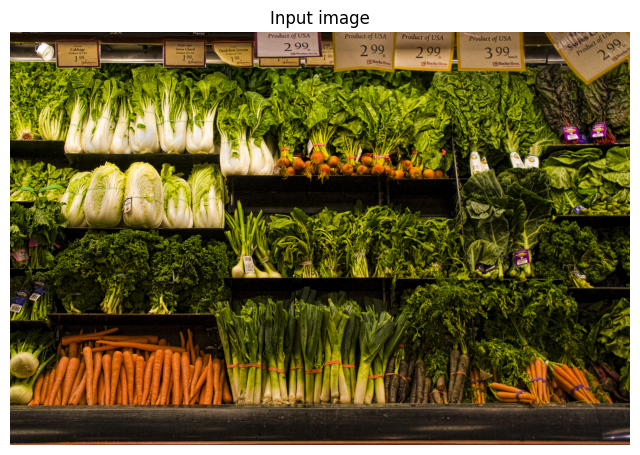

In [8]:
display_image(im, title="Input image")


Define the model and create the boxes.

In [9]:
def inference(model, msgs):
  # Build the full textual prompt that Qwen-VL expects
  text_prompt = processor.apply_chat_template(
    msgs,
    tokenize=False,
    add_generation_prompt=True
  )
  # Extract vision-modalities from msgs and convert them to model-ready tensors
  image_inputs, video_inputs = process_vision_info(msgs)

  # ── Pack text + vision into model-ready tensors ──────────────────────────────
  inputs = processor(
      text=[text_prompt],      # 1-element batch containing the chat prompt string
      images=image_inputs,     # list of raw PIL images (pre-processed inside processor)
      videos=video_inputs,     # list of raw video clips (if any)
      padding=True,            # pad sequences so text/vision tokens line up in a batch
      return_tensors="pt",     # return a dict of PyTorch tensors (input_ids, pixel_values, …)
  ).to(model.device)           # move every tensor—text & vision—to the model’s GPU/CPU

  # ── Run inference (no gradients, pure generation) ───────────────────────────
  with torch.no_grad():                     # disable autograd to save memory
      generated_ids = model.generate(       # autoregressive decoding
          **inputs,                         # unpack dict into generate(...)
          max_new_tokens=1000               # cap the response to max_new_tokens
      )
  # Extract the newly generated tokens (skip the prompt length)
  output = processor.batch_decode(
      generated_ids[:, inputs.input_ids.shape[-1]:],
      skip_special_tokens=False
  )[0]
  print(f"RAW output:\n {output} \n")

  # The above output will be in the following format
  # ```json
  #  [
	#    {"bbox_2d": [x, y, w, h], "label": "class name"}
  # ]
  # ```<|im_end|>
  # We will use extract_json utility to extract just the JSON object.
  # [
	#    {"bbox_2d": [x, y, w, h], "label": "class name"}
  # ]
  bounding_boxes = extract_json(output)
  print("JSON output:\n")
  pprint.pprint(bounding_boxes, indent=4)
  return bounding_boxes

The next step is the inference step and results presentation.

RAW output:
 ```json
[
	{"bbox_2d": [94, 1586, 1037, 1999], "label": "carrots"},
	{"bbox_2d": [2560, 1740, 3211, 1988], "label": "carrots"}
]
```<|im_end|> 

JSON output:

[   {'bbox_2d': [94, 1586, 1037, 1999], 'label': 'carrots'},
    {'bbox_2d': [2560, 1740, 3211, 1988], 'label': 'carrots'}]


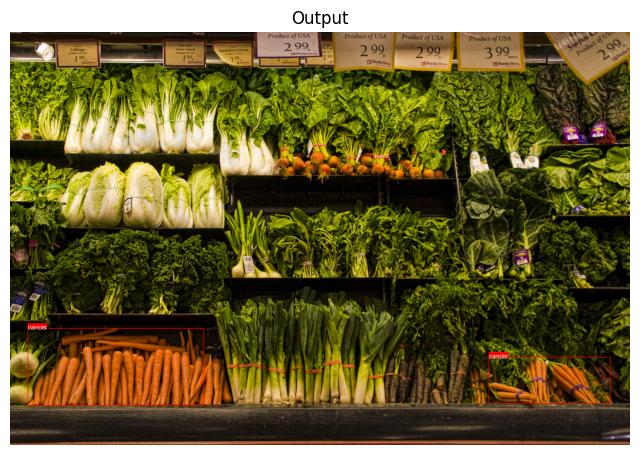

In [10]:
msgs = [
    {
        "role": "system",
        "content": [
            {
                "type": "text",
                "text": (
                    "You are an object detector. The format of your output should be a valid JSON object "
                    "{'bbox_2d': [x1, y1, x2, y2], 'label': 'class'} where class is the name of the class you are detecting."
                )
            }
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": im},
            {
                "type": "text",
                "text": "Outline the position of carrots"
            }
        ],
    }
]

# Run inference
bounding_boxes = inference(model, msgs)

# Draw the bounding boxes on the image
img_out = draw_bboxes(im.copy(), bounding_boxes)

# Display the output
display_image(img_out, title="Output")